# 06. Solving Equations and Minimization:

It is straight forward to numerically solve various equations.  In this lecture we consider four different types of equations to solve:
1. Polynomials
2. Sets of linear equations
3. Nonlinear equations
4. Underdetermined or overdetermined sets of equations(minimizing/optimizing)


## Polynomial:  

Problem:  Calculate the intersection of the line $\vec{x}=\vec{x0} + d\hat{n}$ with the cone with axis $\hat{n_c},$ vertex $\vec{v},$ height $h=1$ m and opening angle $\alpha=\pi/6.$  Write the functions generally, but start with values $\vec{x_0}=(2,1,4)$ m, $\hat{n}=(.6, 0, .8)$, $\vec{v}=(0,0,0),\hat{n_c}=(0,0,1)$

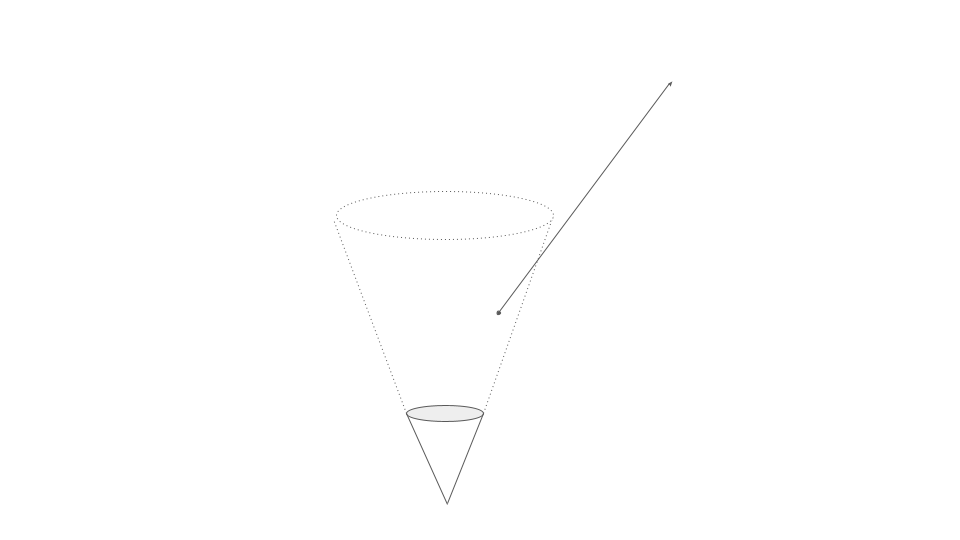
The vector equation of a cone is 
$$\cos^2\alpha\ (\vec{x}-\vec{v})^2=\left((\vec{x}-\vec{v})\cdot \hat{n_c}\right)^2$$

This equation just says that the point on the cone is on the hypotenuse of a triangle, with adjacent leg along the axis.  Note that the left hand side is the square of a vector, while the right hand side is the square of a number.

To iterate the obvious, the vector $(\vec{x}-\vec{v})\cdot \hat{n_c}$ is the vector $\vec{x}-\vec{v}$ projected onto $\hat{n_c}$- that is, the height of that point.  If we project $\vec{x}-\vec{v}$ onto the plane with normal $\hat{n_c}$ we get $(\vec{x}-\vec{v})-(\vec{x}-\vec{v})\cdot \hat{n_c}\hat{n_c}$.

The vector equation of  the plane at the base of the cone is $\vec{x}\cdot \hat{n_c}=h$

Our procedure will be to solve the equation of the cone for d, and check that any solutions fall between 0 and h.  Similarly we solve the equation of the plane for d, and check that the radius is less than $1.0/\cos\alpha.$

$$\vec{x}-\vec{v}=\vec{x_0}+d\hat{n}-\vec{v}$$

Substituting in the equation of the line, we want to solve for $d.$
$$\cos^2\alpha(\vec{x}-\vec{v})^2=\cos^2\alpha\left(d^2+2d\hat{n}\cdot(\vec{x_0}-\vec{v})+(\vec{x_0}-\vec{v})^2\right)$$
$$\left((\vec{x}-\vec{v})\cdot \hat{n_c}\right)^2=\left((\vec{x_0}+d\hat{n}-\vec{v})\cdot \hat{n_c}\right)^2 =((\vec{x_0}-\vec{v})\cdot\hat{n_c})^2+2d(\hat{n}\cdot\hat{n_c})\left((\vec{x_0}-\vec{v})\cdot\hat{n_c}\right)+d^2(\hat{n}\cdot\hat{n_c})^2$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# First, do a solution for the cone, ignoring the base.  
x0=np.array([2,1,4])
n=np.array([0.6,0,0.8])
v=np.array([0,0,0])
nc=np.array([0,0,1])
h=1
alpha = np.pi/6.0;
cos2alpha=np.cos(alpha)**2

x0v=x0-v
x0vDotnc=np.dot(x0v,nc)
nnc=np.dot(n,nc)
#now gather the coefficients:
P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])

solutions=P.roots()

position=x0+solutions[0]*n
print(f'The intersection with the cone is {position}.')
solutions


The intersection with the cone is [0.39827727 1.         1.86436969].


array([-2.66953788,  0.85135607])

## Aside: conic sections

To check, and to generalize, let's define a function that sets $\hat{n}=(\cos\theta,0,\sin\theta)$; this will give the intersection of a cone with a plane (perpendicular to the y axis), which we know is a conic section.

(-20.0, 20.0)

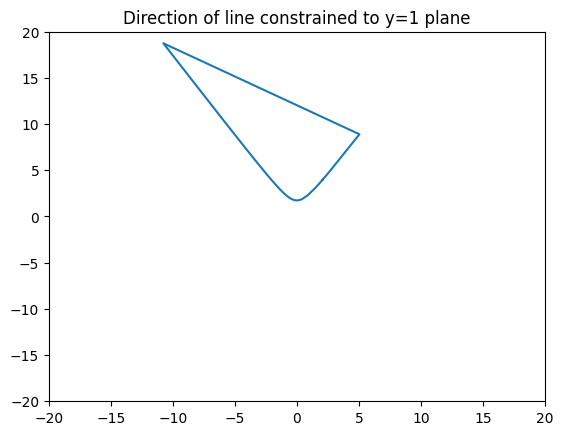

In [6]:
def position(theta):
    '''For each theta, forms a direction, and calculates the 3-vector position of the intersection between a 
    line and a cone'''
    retval=[]
    for t in theta:
        n=np.array([np.cos(t),0,np.sin(t)])
        nnc=np.dot(n,nc)
        P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])
        solutions=P.roots()
     #   print(solutions)
        if solutions[1]>0:
            if solutions[0]>0 and np.linalg.norm(x0+solutions[0]*n)<25:
                retval.append(x0+solutions[0]*n)
            elif np.linalg.norm(x0+solutions[1]*n)<25:
                retval.append(x0+solutions[1]*n)

    return np.array(retval)

tlist=np.linspace(0,2*np.pi,100)
plist=position(tlist)
plt.plot(plist[:,0],plist[:,2])
plt.title('Direction of line constrained to y=1 plane')
plt.xlim([-20,20])
plt.ylim([-20,20])

Qualitatively, this does look like an hyperbola.  We could check it carefully, but will leave that for an exercise.  The "cross line" at the top is where the solution wraps around from right to left.  Check that out by changing the number of points in the tlist linspace.

To validate, double check that every point in plist satisfies the cone equation:

Text(0.5, 1.0, 'Test of cone equation for all the solutions')

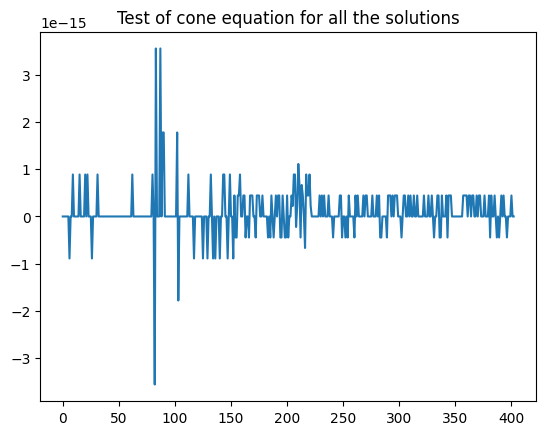

In [4]:
test=[np.linalg.norm(x-v)*np.cos(alpha)-np.dot(x-v,nc) for x in plist]
plt.plot(test)
plt.title('Test of cone equation for all the solutions')

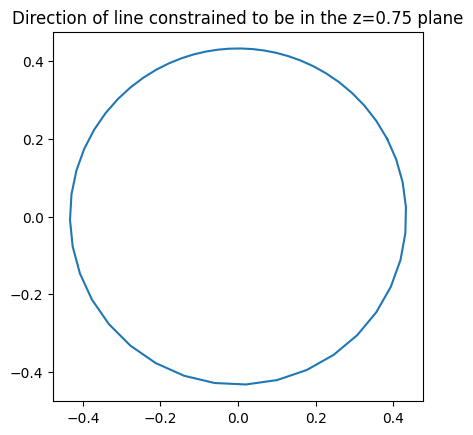

In [5]:
x0=np.array([0,0.2,.75])
x0v=x0-v
x0vDotnc=np.dot(x0v,nc)

def position2(theta):
    '''For each theta, forms a direction, and calculates the 3-vector position of the intersection between a 
    line and a cone.  Pick n in a plane perpendicular to n_c'''
    retval=[]

    for t in theta:
        n=np.array([np.cos(t),np.sin(t),0])
        nnc=np.dot(n,nc)
        P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])
        solutions=P.roots()
#        print(solutions)
        if solutions[0]>0:
            retval.append(x0+solutions[0]*n)
        elif solutions[1]>0:
            retval.append(x0+solutions[1]*n)

    return np.array(retval)
tlist=np.linspace(0,2*np.pi,50)
plist=position2(tlist)
plt.plot(plist[:,0],plist[:,1])
plt.axis('scaled')
plt.title('Direction of line constrained to be in the z=0.75 plane')
plt.show()


Text(0.5, 1.0, 'Deviation of solution from equation of cone')

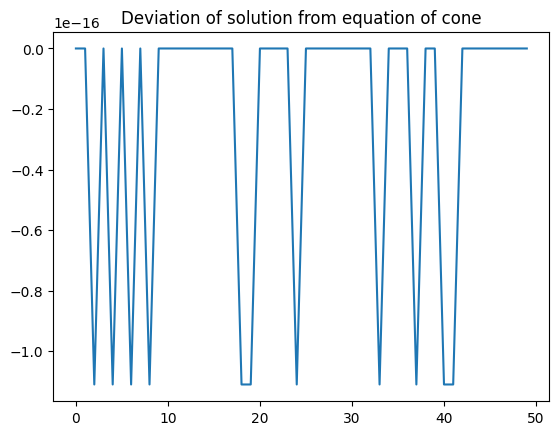

In [6]:
test=[np.linalg.norm(x-v)*np.cos(alpha)-np.dot(x-v,nc) for x in plist]
plt.plot(test)
plt.title('Deviation of solution from equation of cone')

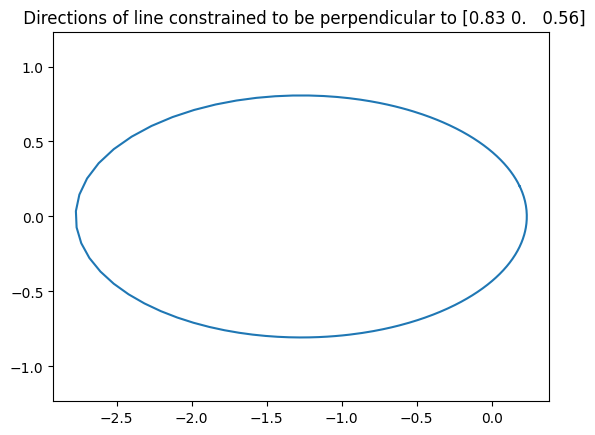

In [7]:
# now use n in plane at an angle to n_c

n_plane=np.array([np.cos(0.6),0,np.sin(0.6)]) # small tilt with respect to the z-axis.
x0=np.array([0,0.2,.75])
x0v=x0-v
x0vDotnc=np.dot(x0v,nc)

def position3(theta):
    '''For each theta, forms a direction, and calculates the 3-vector position of the intersection between a 
    line and a cone.  Pick n in a plane perpendicular to n_c'''
    retval=[]

    for t in theta:
        n=np.array([np.cos(t),np.sin(t),0])
        n=n-np.dot(n,n_plane)*n_plane  #project onto n_plane-- see that n*n_plane is now 0
        n=n/np.linalg.norm(n)
        nnc=np.dot(n,nc)
        P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])
        solutions=P.roots()
#        print(solutions)
        if solutions[0]>0:
            retval.append(x0+solutions[0]*n)
        elif solutions[1]>0:
            retval.append(x0+solutions[1]*n)

    return np.array(retval)
tlist=np.linspace(0,2*np.pi,500)
plist=position3(tlist)
plt.plot(plist[:,0],plist[:,1])
np.set_printoptions(precision=2)
plt.title(f' Directions of line constrained to be perpendicular to {n_plane}')
plt.axis('equal')
plt.show()

## Back to the intersection with the original cone.

We now add code that calculates the intersection with the plane z=1.  
And check that valid intersections z values between 0 and 1, and if z=1, have radius less than $h\tan \alpha.$

In [8]:
x0=np.array([1,0.5,2])  # changed this value to get a real solution.
n=np.array([-0.6,0,-0.8])
v=np.array([0,0,0])
nc=np.array([0,0,1])
h=1
alpha = np.pi/6.0;
cos2alpha=np.cos(alpha)**2

x0v=x0-v
x0vDotnc=np.dot(x0v,nc)
nnc=np.dot(n,nc)
#now gather the coefficients:
P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])


#find solution to plane nc*(x0+dn)=1 
d=(1-np.dot(x0,nc))/nnc
position=x0+d*n
print(f"plane intersection {position}")
solutions=[]
if np.linalg.norm(position-np.dot(position,nc)*nc)<h*np.tan(alpha):
    solutions.append(position)

# now find solution to cone
for d in P.roots():  #only keep positive solutions
    if d>0:
        position=x0+d*n
        if 0<np.dot(position-v,nc)<=h:
            solutions.append(position)
print(solutions)
print(f'The intersection with the cone is {solutions}.')


plane intersection [0.25 0.5  1.  ]
[array([0.25, 0.5 , 1.  ]), array([0.2 , 0.5 , 0.93])]
The intersection with the cone is [array([0.25, 0.5 , 1.  ]), array([0.2 , 0.5 , 0.93])].


Now make a plot scanning the solutions by changing the direction of the line

Text(0, 0.5, 'z')

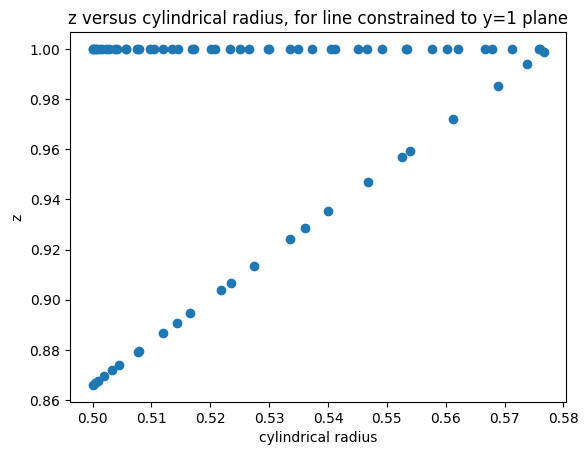

In [9]:
def position4(theta):
    '''For each theta, forms a direction, and calculates the 3-vector position of the intersection between a 
    line and a cone'''
    solutions=[]
    for t in theta:
        n=np.array([np.cos(t),0,np.sin(t)])
        nnc=np.dot(n,nc)
        P=np.polynomial.Polynomial([cos2alpha*np.dot(x0v,x0v)-x0vDotnc**2,2*cos2alpha*np.dot(n,x0v)-2*nnc*x0vDotnc,
                           cos2alpha-nnc**2])
        if nnc != 0:  # if nnc ==0 there is no solution for the plane
            d=(1-np.dot(x0,nc))/nnc
            position=x0+d*n
            if np.linalg.norm(position-np.dot(position,nc)*nc)<h*np.tan(alpha):
                solutions.append(position)

        # now find solution to cone
        for d in P.roots():  
            if d>0:
                position=x0+d*n
                if 0<np.dot(position-v,nc)<=h: #only keep solutions that hit physical cone
                    solutions.append(position)

    return np.array(solutions)

tlist=np.linspace(0,2*np.pi,500)
plist=position4(tlist)
plt.plot(np.sqrt(plist[:,0]**2+plist[:,1]**2),plist[:,2],'o')
plt.title('z versus cylindrical radius, for line constrained to y=1 plane')
plt.xlabel('cylindrical radius')
plt.ylabel('z')

## Sets of Linear Equations

Problem (from Halliday and Resnick, Fundamentals of Physics, Extended Third Edition, 1988)
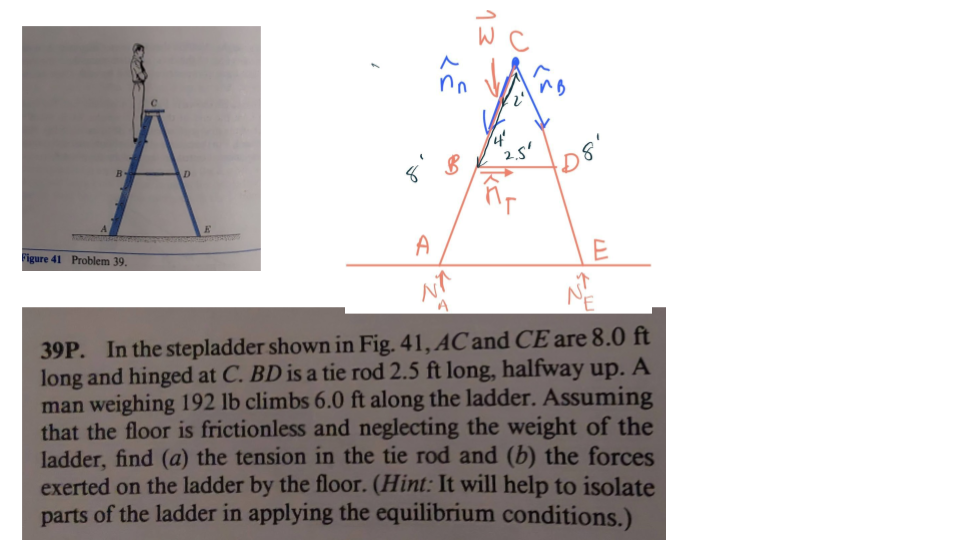


This is a straightforward problem, and we could lay it out the way Halliday and Resnick intended.  We will do it a little differently, to highlight numerical solutions of systems of equations.

There are three unknowns- the tension $T$ in the tie rod, and the normal forces $N_A$ and $N_E$ at the floor.
We want to set up a system of three equations that will look like:

$$ \bf{M}\bf{V}=\bf{A}\rightarrow \left(\begin{array}{ccc} m_{00} &m_{01}&m_{02}\\ m_{10} &m_{11}&m_{12} \\ m_{20} &m_{21}&m_{22} \end{array}\right)\left( \begin{array}{c} T\\ N_A \\ N_E \end{array}\right) =\left( \begin{array}{c}a\\b\\c\end{array}\right)$$

We set **M,V,A** as numpy arrays, and use numpy.linalg.inv to invert **M**.  Then

$$\bf{V}=\bf{M}^{-1}\bf{A}$$

There are three equations- the first from the forces (all of which are vertical), the second from the sum of the torques on the left leg of the ladder, and the third from the torques on the right leg of the ladder.  We take the torques around the pivot, C, since we don't know the forces at the pivot.  (However, the torques due to the forces at the pivot are zero).

The force equation $N_A+N_E=W$ becomes:
$$ \left(\begin{array}{ccc} 0 &1 &1 \\ m_{10} &m_{11}&m_{12} \\ m_{20} &m_{21}&m_{22} \end{array}\right)\left( \begin{array}{c} T\\ N_A \\ N_E \end{array}\right) =\left( \begin{array}{c}W\\b\\c\end{array}\right)$$

The torque equation on the left leg $\sum \vec{\tau_i}=0\rightarrow \sum \vec{r_i}\times \vec{F_i}=0$:

$$-2W\hat{n_{CA}}\times \hat{k}+4T\hat{n_{CA}}\times \vec{n_{BD}}+8N_A\hat{n_{CA}}\times \hat{k}=0$$

Here $\hat{k}$ is a unit vector that is vertical, the other unit vectors are labelled by the vertices on the ladder, and the 2, 4, and 8 come from the positions along the leg CA where the force is applied.  Since all the vectors are in the x-z plane (x right and z up) all the torques are in the y-direction. 

$$ \left(\begin{array}{ccc} 0 &1 &1 \\4\hat{n_{CA}}\times \vec{n_{BD}}  &8\hat{n_{CA}}\times \hat{k}&0 \\m_{20}  &m_{21}&m_{22} \end{array}\right)\left( \begin{array}{c} T\\ N_A \\ N_E \end{array}\right) =\left( \begin{array}{c}W\\2W\hat{n_{CA}}\times \hat{k} \\c\end{array}\right)$$

On the right leg we have
$$-4T\hat{n_{CE}}\times \vec{n_{BD}}+8N_E\hat{n_{CE}}\times \hat{k}=0$$

which then makes the matrix equation:
$$ \left(\begin{array}{ccc} 0 &1 &1 \\
4\hat{n_{CA}}\times \vec{n_{BD}}  &8\hat{n_{CA}}\times \hat{k}&0 \\ 
-4\hat{n_{CE}}\times \vec{n_{BD}} &0& 8\hat{n_{CE}}\times \hat{k} \end{array}\right)\left( \begin{array}{c} T\\ N_A \\ N_E \end{array}\right) =\left( \begin{array}{c}W\\2W\hat{n_{CA}}\times \hat{k} \\0\end{array}\right)$$

with the proviso that all that should go into the matrix is the y-component of the vector manipulations.

Now we translate into python:


In [10]:
k=np.array([0,0,1])
nca=np.array([-2.5,0,-np.sqrt(8**2-2.5**2)])
nca=nca/np.linalg.norm(nca) #unit vector
nce=np.array([2.5,0,-np.sqrt(8**2-2.5**2)])
nce=nce/np.linalg.norm(nce) #unit vector
nbd=np.array([1,0,0])
W=192  #force in pounds!

M=np.array([[0,1,1],[4*np.cross(nca,nbd)[1],8*np.cross(nca,k)[1],0],[-4*np.cross(nce,nbd)[1],0,8*np.cross(nce,k)[1]]])
A=np.array([[W],[2*W*np.cross(nca,k)[1]],[0]])
Minverse=np.linalg.inv(M)
V=Minverse@A


print(f'The tension in the tie rod is {V[0][0]:5.1f} lb, the normal force at A is {V[1][0]}lb. and the normal force at B is {V[2][0]} lb.')

The tension in the tie rod is  47.4 lb, the normal force at A is 120.0lb. and the normal force at B is 72.0 lb.


In [11]:
print(M)

[[ 0.   1.   1. ]
 [-3.8  2.5  0. ]
 [ 3.8  0.  -2.5]]


This is very straight forward.  But there is no problem for the computer to invert very large matrices; and it often does so during numerical operations.  
The basic procedure is the same.  Instead of 2 legs and tie rod, we would do the problem essentially the same way for a complicated structure/building with dozens of support beams and interconnections.  Although the matrices would get larger with the number of unknowns, the way you would do the equations is exactly the same- make the sum of torques and sum of forces all zero.  

There are some specialized operations/inversions- so it is worth looking at the documentation if you have sparse or other matrices.

# Solving Non-linear Equations

Non linear equations have their own solvers.  In particular scipy.optimize provices scipy.optimize.roots and scipy.optimize.fsolve that allow you to solve a system of equations.  fsolve and roots are a little redundant; roots, however, enables interfacing to several different solvers so it is probably the best to use. roots allows the simultaneous solution of several equations; root_scalar is available for a scalar equation.

There are a variety of techniques that people have figured out- including bisections, secant solvers, gradient and approximations.  At this level, there is not a big difference between solving (finding where the solution is zero) and minimizing (finding where a derivative is zero), so we will find that we use the same library for both functions.  (and that is the reason the solver is included in the "optimize" library).

As for matrix inversion, we start with a couple of simple physics examples.

(Halliday and Resnick, sample problem 10-11)
A nuclear reaction of great importance for the generation of energy by nuclear fusion is the d-d reaction:
$$d+d\rightarrow t+p+4.03\rm{~MeV}$$
where $d$ stands for a deuteron with mass 1.00783 u, $p$ for a proton with mass 2.01410 u, and $t$ for a triton (tritium, or $^3$H nucleus) with mass 3.01605 u.  1u has a mass equivalence of 932 MeV.  

A deuteron of kinetic energy 1.50 MeV strikes a resting deuteron, initiating the reaction.  The triton goes off with an angle $\theta$.  Calculate the kinetic energies of the triton and proton.

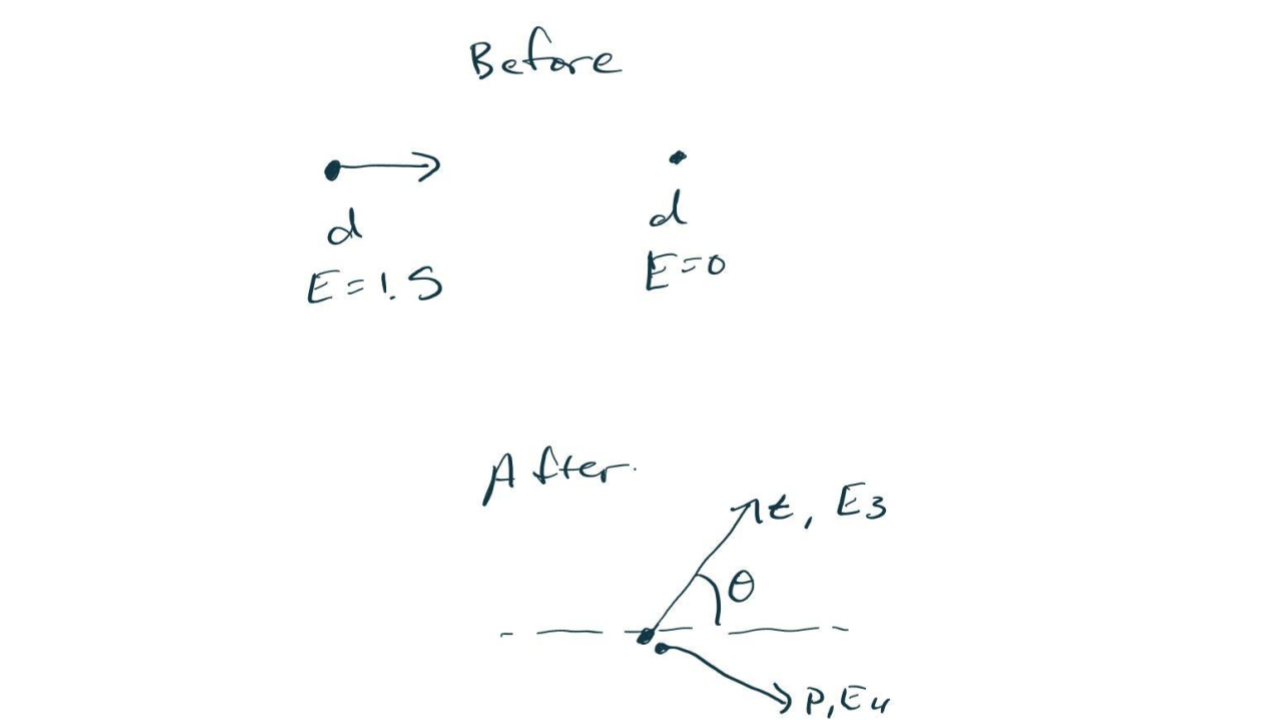

*Physics*

We conserve energy and momentum.  We know the initial momentum and the total energy, and calculate the final energy and momentum in terms of two parameters-- the total energy change and the difference $E-p^2/2m$ for the proton.  If we find the root of these coupled equations, energy and momentum will both be conserved.

*Numerics*

We define a function,scatter, with argument (E3,E4)-- the proposed energy of the triton and proton, and a parameter $\theta$ that tells us the scattering angle of the triton.  

We know the initial kinetic energy is 1.50 MeV, and the final kinetic energy is 1.5+4.03=5.53 MeV.
The initial momentum is defined to be along the x-axis, with  magnitude $\sqrt{2mE}.$ We can calculate the momentum of the triton from its scattering angle and energy; the momentum of the proton needs to be $\vec{p_p}=\vec{p_d}-\vec{p_t}$. The function then calculates and returns the change in the total energy, and the difference $E4-\frac{\vec{p_p}^2}{2m_p}$.

*Validation*

We check that energy is conserved, calculating based on the magnitudes of the momenta.  We check that initial momentum = final momentum.

In [11]:
m1c2=2.01410 *932#MeV
E1=1.50 #MeV
p1c=np.array([1,0])*np.sqrt(2*m1c2*E1)
m3c2=3.01605*932 #  triton
m4c2=1.00783 *932 #proton
DeltaE=4.03 #MeV

def scatter(arg,theta):
    '''Returns a tuple- initial energy-final energy, proton energy from parameter- proton energy from momentum'''
    global p3c,p4c
    E3,E4=arg
    p3c=np.array([np.cos(theta),np.sin(theta)])*np.sqrt(2*m3c2*E3)
    p4c=p1c-p3c
    return(E1+DeltaE-E3-E4,E4-np.dot(p4c,p4c)/2/m4c2)

from scipy.optimize import root
# do a test picking a particular value of theta
solution=root(scatter,np.array([1,4]),args=(0.25,))
print(solution,'\n\n\n')

print(f'Energy of triton is {solution.x[0]:5.2f} and energy of proton is {solution.x[1]:5.2f} MeV.')

#verification-- check that the solution satisfies energy and momentum conservation.
print(f'p^2/2m for triton is {np.dot(p3c,p3c)/m3c2/2:5.2f} and for proton is {np.dot(p4c,p4c)/m4c2/2:5.2f}')
print(f'p3+p4={p3c+p4c}, cf p1={p1c}')

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  8.882e-16]
       x: [ 3.258e+00  2.272e+00]
  method: hybr
    nfev: 10
    fjac: [[-8.778e-01 -4.791e-01]
           [ 4.791e-01 -8.778e-01]]
       r: [ 1.139e+00 -3.305e-03 -2.093e+00]
     qtf: [ 8.984e-12  1.646e-11] 



Energy of triton is  3.26 and energy of proton is  2.27 MeV.
p^2/2m for triton is  3.26 and for proton is  2.27
p3+p4=[75.04  0.  ], cf p1=[75.04  0.  ]


The output of root is a list of several things- including "fun", the value of the function evaluated at the solution, and the solution itself,"x".   

In [5]:
help(solution)

Help on OptimizeResult in module scipy.optimize._optimize object:

class OptimizeResult(builtins.dict)
 |  Represents the optimization result.
 |  
 |  Attributes
 |  ----------
 |  x : ndarray
 |      The solution of the optimization.
 |  success : bool
 |      Whether or not the optimizer exited successfully.
 |  status : int
 |      Termination status of the optimizer. Its value depends on the
 |      underlying solver. Refer to `message` for details.
 |  message : str
 |      Description of the cause of the termination.
 |  fun, jac, hess: ndarray
 |      Values of objective function, its Jacobian and its Hessian (if
 |      available). The Hessians may be approximations, see the documentation
 |      of the function in question.
 |  hess_inv : object
 |      Inverse of the objective function's Hessian; may be an approximation.
 |      Not available for all solvers. The type of this attribute may be
 |      either np.ndarray or scipy.sparse.linalg.LinearOperator.
 |  nfev, njev, nh

In [15]:
theta=np.linspace(0,2.005,100)  #  if we go past 2.005 radians, we no longer find solutions.  why?
energy=np.array([root(scatter,np.array([1,1]),args=(t)).x[0] for t in theta])

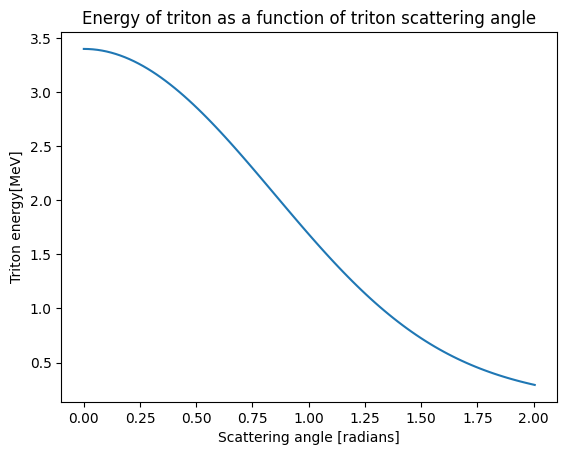

In [13]:
plt.plot(theta,energy)
plt.title('Energy of triton as a function of triton scattering angle')
plt.xlabel('Scattering angle [radians]')
plt.ylabel('Triton energy[MeV]')
plt.show()

Example 2. Statics again.  
We have a plank of length 2 meters and mass 20 kg, suspended by 2 ropes each of length 2.5 meters, from walls that are 5 meters apart.  A mass of 100 kg is located x meters from one end of the plank.  Calculate the tensions in the two ropes and the angles of the two ropes as a function of x.

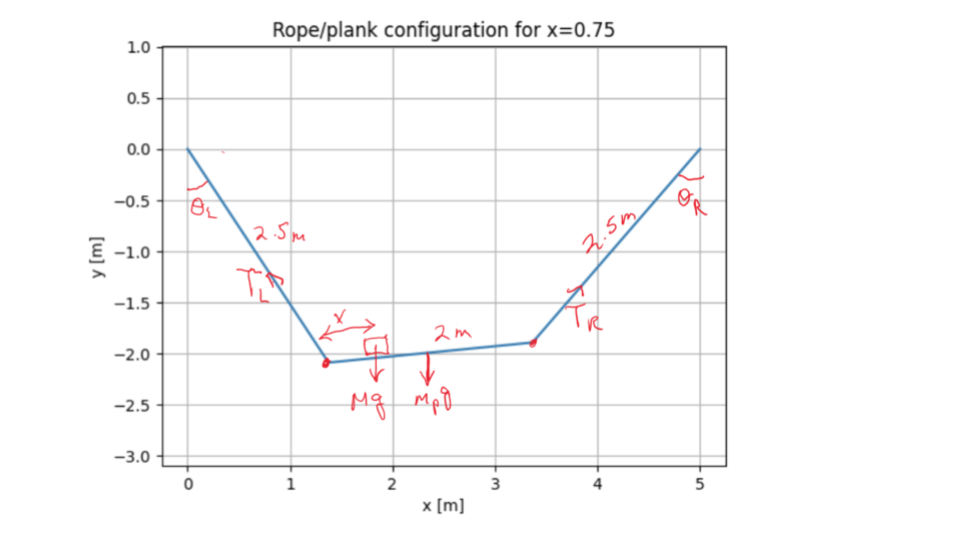

*Numerics*
Our first thought is that the function returns three values-- the sum of forces in the horizontal direction, the sum of forces in the vertical direction, and the sum of torques about one end of the plank. The input parameters will be Tl, Tr, and thetal (the angle for left rope); x will be an additional argument.  The solver will vary Tl, Tr, and thetal until it finds a set which make the outputs zero.
  
This would be the case if it was easy to impose the geometrical constraint-- the relationship between $\theta_l$ and $\theta_r.$  But after a quick sketch, it is a little complicated, so we will add a fourth input variable- $\theta_r$, and a fourth output- the $L-|\vec{x_l}-\vec{x_r}|$, where L is the length of the plank and the vectors refer to the places where the lines join the plank. 

We will set things up with the origin at the left rope anchor,  x axis horizontally, and the y axis vertically.  The torques are along the z axis.

In [16]:
L=2 #meters, length of the plank
mP=20 #kg, mass of the plank
m=100 #kg, mass of the moveable object
ropeLength=2.5 #meter, length of the ropes

Dr=np.array([5,0,0]) #meters, position of the right rope anchors (upper pivot)
v=np.array([0,1,0]) # vertical unit axis
g=9.8 #m/s/s acceleration due to gravity

def static(arg,x):
    '''Input parameters: arg= tuple of left tension, right tension, left angle, right angle
       x= position of 100 kg mass with respect to the left end of the plank
       return value: tuple of sum of horizontal forces, sum of vertical forces, sum of torques, 
                    difference between plank length and positions of ends of ropes'''
    global nl,nr,nPlank #make these global so we can use them to draw a figure later.
    Tl,Tr,thetal,thetar=arg
    nl=np.array([np.sin(thetal),-np.cos(thetal),0])  # unit vector along left rope
    nr=np.array([-np.sin(thetar),-np.cos(thetar),0]) # unit vector along right rope
    Plank=Dr+ropeLength*nr-ropeLength*nl  # vector from left plank end to right plank end
    nPlank=Plank/np.linalg.norm(Plank)
    forceSum=-Tl*nl-Tr*nr-(m+mP)*g*v # forces on the plank
    torqueSum=mP*g*L/2*np.cross(nPlank,-v)+m*g*x*np.cross(nPlank,-v)-L*Tr*np.cross(nPlank,nr)
    return(forceSum[0],forceSum[1],torqueSum[2],L-np.linalg.norm(Dr+ropeLength*nr-ropeLength*nl))
    
    
# test picking a sample x.
x=2 #m
root(static,np.array([600,600,0.3,0.3]),args=x)

 message: The solution converged.
 success: True
  status: 1
     fun: [-2.091e-09 -3.011e-09 -9.728e-09  2.388e-12]
       x: [ 5.290e+02  9.811e+02  9.730e-01  4.620e-01]
  method: hybr
    nfev: 23
    fjac: [[-8.332e-01  5.104e-01 -2.126e-01 -4.556e-05]
           [-7.345e-02 -4.832e-01 -8.724e-01  3.128e-05]
           [ 5.480e-01  7.113e-01 -4.401e-01 -4.618e-04]
           [-2.174e-04 -3.668e-04  1.856e-04 -1.000e+00]]
       r: [ 1.031e+00 -3.590e-01 -2.317e+02 -1.028e+03 -2.311e+00
           -8.078e+02 -1.818e+02 -1.004e+03  1.552e+02 -2.475e+00]
     qtf: [ 7.083e-08  3.230e-07  4.009e-08 -7.809e-11]

In [17]:
xlist=np.linspace(0,2)  # get list of positions of movable mass
sol=np.array([root(static,np.array([750,750,.6,.6]),args=x).x for x in xlist ])

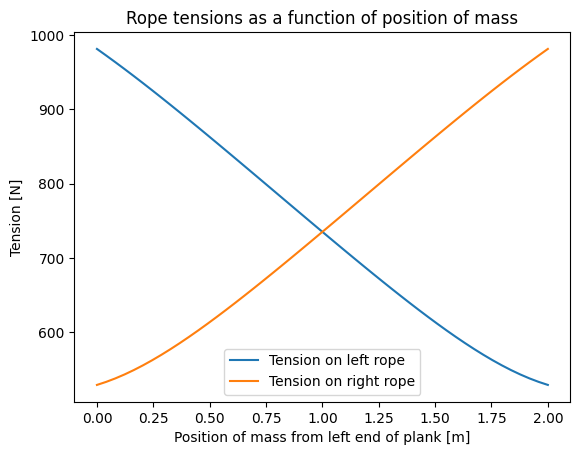

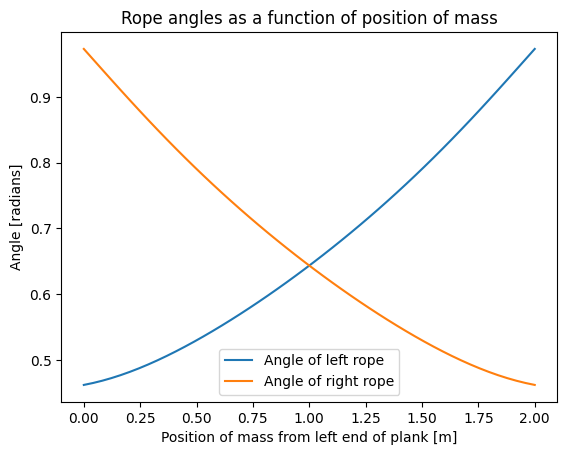

In [18]:
plt.plot(xlist,sol[:,0],label='Tension on left rope')
plt.plot(xlist,sol[:,1],label='Tension on right rope')
plt.legend()
plt.title("Rope tensions as a function of position of mass")
plt.xlabel("Position of mass from left end of plank [m]")
plt.ylabel("Tension [N]")
plt.show()

plt.plot(xlist,sol[:,2],label='Angle of left rope')
plt.plot(xlist,sol[:,3],label='Angle of right rope')
plt.legend()
plt.title("Rope angles as a function of position of mass")
plt.xlabel("Position of mass from left end of plank [m]")
plt.ylabel("Angle [radians]")
plt.show()

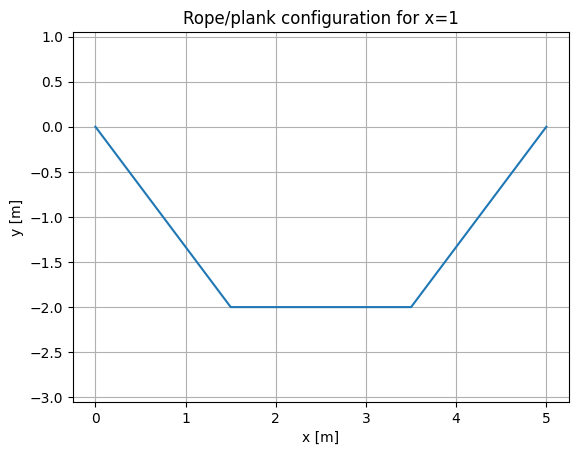

In [11]:
# Now let's draw the configuration for a few values of x

x=1
tl,tr,thetal,thetar=root(static,np.array([600,600,0.3,0.3]),args=x).x  #get solution values
xlist=np.array([np.zeros(3),ropeLength*nl,L*nPlank,-ropeLength*nr])
xlist2=np.cumsum(xlist,axis=0)
plt.title(f'Rope/plank configuration for x={x}')
plt.xlabel("x [m]")
plt.ylabel('y [m]')
plt.plot(xlist2[:,0],xlist2[:,1])
plt.axis('equal')
plt.grid()
plt.show()


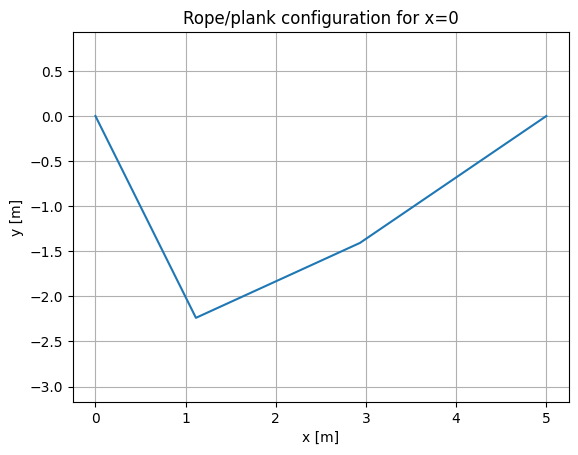

In [12]:
x=0
tl,tr,thetal,thetar=root(static,np.array([600,600,0.3,0.3]),args=x).x  #get solution values
xlist=np.array([np.zeros(3),ropeLength*nl,L*nPlank,-ropeLength*nr])
xlist2=np.cumsum(xlist,axis=0)
plt.plot(xlist2[:,0],xlist2[:,1])
plt.axis('equal')
plt.title(f'Rope/plank configuration for x={x}')
plt.xlabel("x [m]")
plt.ylabel('y [m]')
plt.grid()
plt.show()

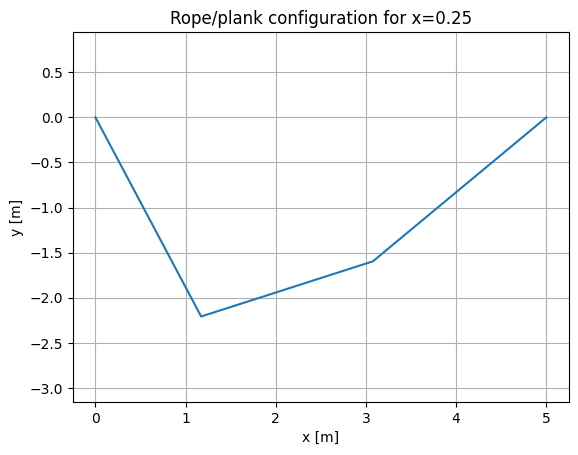

In [13]:
x=0.25
tl,tr,thetal,thetar=root(static,np.array([600,600,0.3,0.3]),args=x).x  #get solution values
xlist=np.array([np.zeros(3),ropeLength*nl,L*nPlank,-ropeLength*nr])
xlist2=np.cumsum(xlist,axis=0)
plt.plot(xlist2[:,0],xlist2[:,1])
plt.axis('equal')
plt.title(f'Rope/plank configuration for x={x}')
plt.xlabel("x [m]")
plt.ylabel('y [m]')
plt.grid()
plt.show()


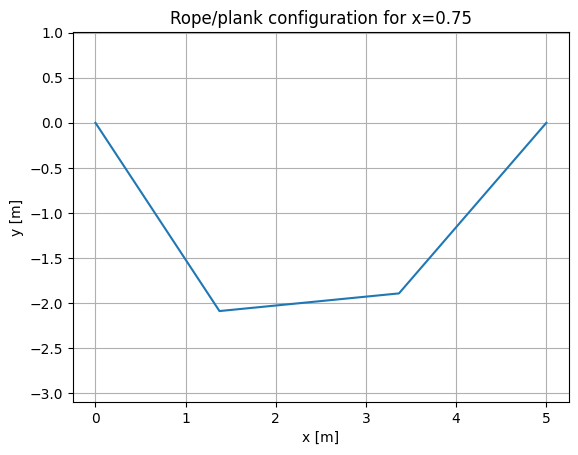

In [14]:
x=0.75
tl,tr,thetal,thetar=root(static,np.array([600,600,0.3,0.3]),args=x).x  #get solution values
xlist=np.array([np.zeros(3),ropeLength*nl,L*nPlank,-ropeLength*nr])
xlist2=np.cumsum(xlist,axis=0)
plt.plot(xlist2[:,0],xlist2[:,1])
plt.axis('equal')
plt.title(f'Rope/plank configuration for x={x}')
plt.xlabel("x [m]")
plt.ylabel('y [m]')
plt.grid()
plt.savefig("plank.png")
plt.show()


# root_scalar

In [10]:
# use root_scalar for a simple non-linear equation.
from scipy.optimize import root_scalar
help(root_scalar)

Help on function root_scalar in module scipy.optimize._root_scalar:

root_scalar(f, args=(), method=None, bracket=None, fprime=None, fprime2=None, x0=None, x1=None, xtol=None, rtol=None, maxiter=None, options=None)
    Find a root of a scalar function.
    
    Parameters
    ----------
    f : callable
        A function to find a root of.
    args : tuple, optional
        Extra arguments passed to the objective function and its derivative(s).
    method : str, optional
        Type of solver.  Should be one of
    
            - 'bisect'    :ref:`(see here) <optimize.root_scalar-bisect>`
            - 'brentq'    :ref:`(see here) <optimize.root_scalar-brentq>`
            - 'brenth'    :ref:`(see here) <optimize.root_scalar-brenth>`
            - 'ridder'    :ref:`(see here) <optimize.root_scalar-ridder>`
            - 'toms748'    :ref:`(see here) <optimize.root_scalar-toms748>`
            - 'newton'    :ref:`(see here) <optimize.root_scalar-newton>`
            - 'secant'    :ref

## Underdetermined or Overdetermined sets of equations-- Minimization

It is often the case that we have fewer variables than equations; experiments in particular can have millions of data points (each the equivalent of an "equation")  which we fit with models with many fewer parameters.  In those cases, we look for approximate solutions- ones that minimize or maximize some goodness parameters.  

We end up using the same general functions (in scipy.optimize) to find the "best" solutions.  

### Example:  Chi-square optimization of the magnetic force model.

We have data from the force measurement between two magnetized spheres, that we used a couple weeks ago.  
We pick up the data from a file, "Magnet_1.csv", which has the force along with the separation for an automated  double scan.  The field calculation was stored in "field.pickle", which we simply read in, interpolate, and then integrate to find the force.  



Text(0, 0.5, 'Force from integration-measurement [N]')

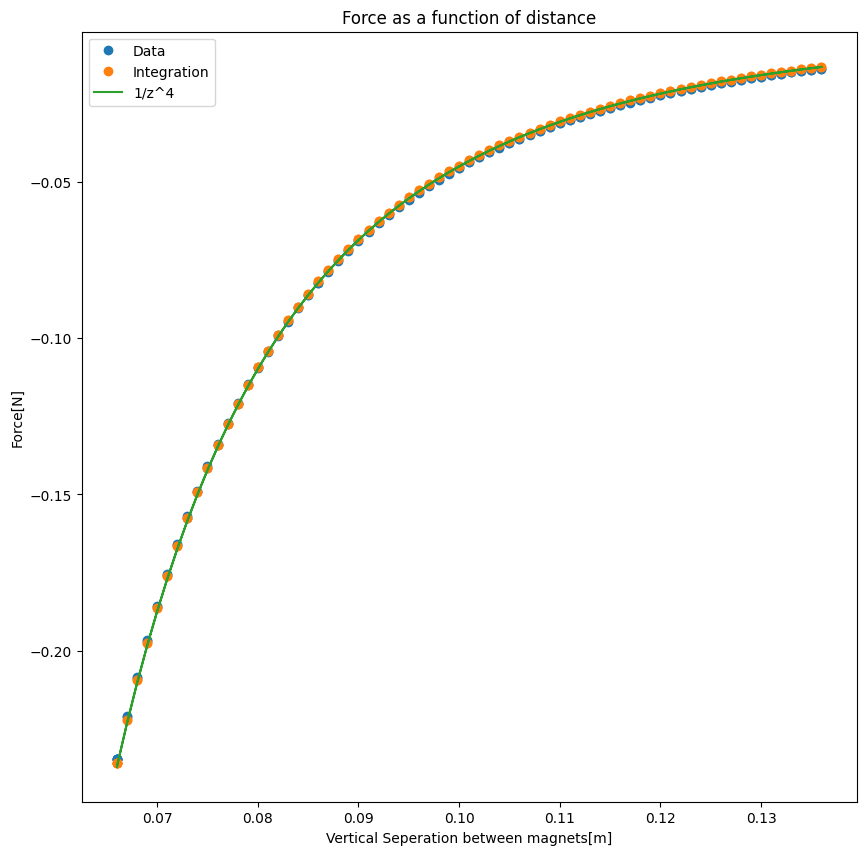

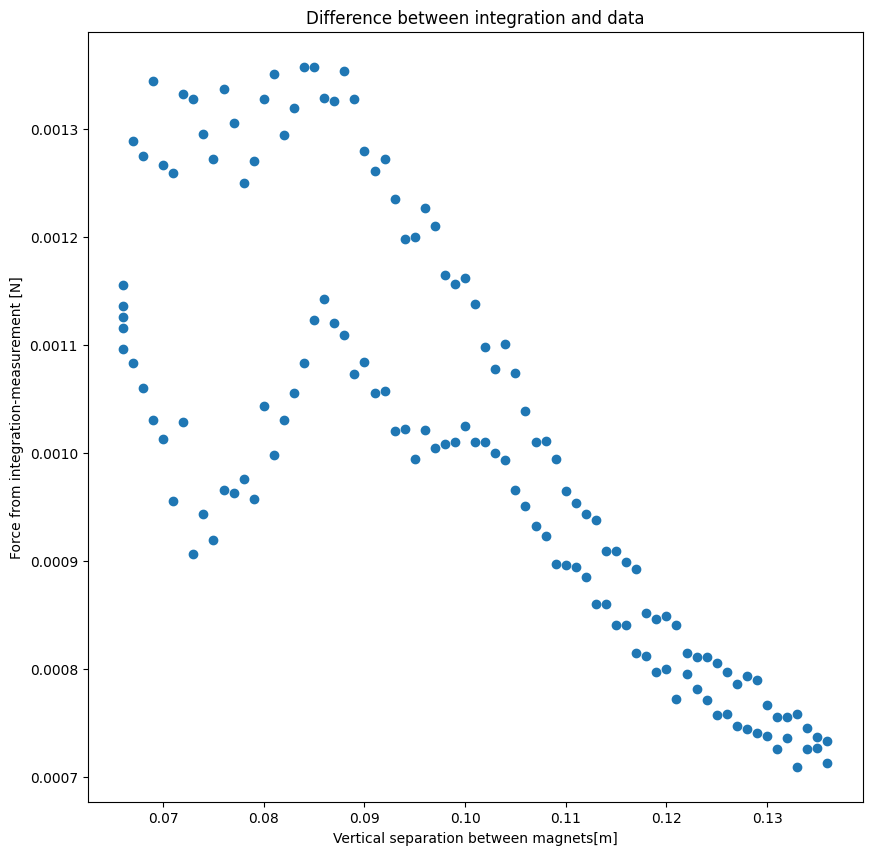

In [19]:
import math
import pickle
from scipy.interpolate import RectBivariateSpline
from scipy.integrate import dblquad

#parameters of magnets
mu0over4pi=1e-7 
M=np.array([0,0,1])  #  we don't know the magnetization, so we calculate it for for 1 and then scale at the end.
r_s=0.025/2 # m radius of base sphere
r2_s=0.0127/2 # m  radius of moving sphere    

read=True
if(read):
    with open('field.pickle','rb')as f:
        Bx,Bz,xsteps,zsteps=pickle.load(f)
else:
    fields=(Bx,Bz,xsteps,zsteps)
    with open('field.pickle','wb') as f:
        pickle.dump(fields,f)

#Set up an interpolation grid for the field.  This speeds up the following integration.

BzInt=RectBivariateSpline(xsteps,zsteps,Bz)
BrhoInt=RectBivariateSpline(xsteps,zsteps,Bx)
    
def BInt(r):
    rho=math.sqrt(r[0]*r[0]+r[1]*r[1])
    Bfield=np.array([r[0]/rho*BrhoInt(rho,r[2])[0,0],r[1]/rho*BrhoInt(rho,r[2])[0,0],BzInt(rho,r[2])[0,0]] )
    return Bfield

M2=np.array([0,0,1.0])
counter=0
def dF(phi,theta):
    global counter
    counter=counter + 1
    n2=np.array([math.sin(theta)*math.cos(phi),math.sin(theta)*math.sin(phi),math.cos(theta)])
    rprime=r2+r2_s*n2
    value=np.cross(np.cross(M2,n2), BInt(rprime))*r2_s**2*math.sin(theta)
#    print('value',value)
    return value

#Force from I dl cross B
def F(rpos):
    global r2
    r2=rpos
    sol=np.array([dblquad(lambda x,y: dF(x,y)[0],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dF(x,y)[1],0,math.pi,0,2*math.pi)[0],
                  dblquad(lambda x,y: dF(x,y)[2],0,math.pi,0,2*math.pi)[0]])
    return sol

from numpy import genfromtxt
my_data = genfromtxt('Magnet_1.csv', delimiter=',',skip_header=7)

force=[]
for z in my_data[:,3]/1000+0.016:
    force.append(F(np.array([0,0,z])))
force=np.array(force)
plt.figure(figsize=(10,10))
plt.title('Force as a function of distance')
plt.xlabel('Vertical Seperation between magnets[m]')
plt.ylabel('Force[N]')
#  the data need to be shifted- the distance by 16 mm, the force by 1.517 g
plt.plot(my_data[:,3]/1000+0.016,(my_data[:,4]-1.517)*9.8/1000.0,'o',label='Data')
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*0.85e12,'o',label='Integration')
# the 1/z^4 comes from the force between two magnetic dipoles, so should be true for spherical magnets
# if the size went to zero.
plt.plot(my_data[:,3]/1000+0.016,-0.0000045/(my_data[:,3]/1000+0.016)**4,label=r'1/z^4')
plt.legend()
plt.figure(figsize=(10,10))
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*0.842e12-(my_data[:,4]-1.517)*9.8/1000.0,'o')
plt.title(r'Difference between integration and data')
plt.xlabel('Vertical separation between magnets[m]')
plt.ylabel('Force from integration-measurement [N]')


Before using any numerical minimization, we can just do things graphically; especially with a single parameter the magnetization.  

We make plots of the Chisquare-$$\chi^2=\sum_i^N\frac{(y_i-f(x_i))^2}{\sigma_i^2} $$

Here $i$ is a label for a data point, $N$ is the number of data points.  The data have independent parameter $x_i$-- in our case this is the distance between the two magnets, $y_i$ is the dependent data parameter-- in our case the measured force, and $\sigma_i$ is the uncertainty.  $f(x_i)$ is the model calculation of the dependent parameter-- what we calculate the force should be.  

Notice a couple of things about $\chi^2$-- 
1. Since it is the sum of squares it will never be zero
2. We expect $\chi^2\approx N$, if $\sigma$ properly reflects the statistical uncertainty in a data point, since we can find $\sigma$ be finding the RMS of multiple measurements of a parameter.
3. If we think about the $\chi^2$ that should correspond to a $1\sigma$ deviation in the parameter, it should also add 1.  For more parameters it gets more complicated, and you should look it up in Hughes and Hase or in Numerical Recipes. 

We actually have two models- one is the detailed numerical integration of the fields, which depends upon magnetization, while the second is a $A/z^4$ model that we used to validate, and which calculates the force between ideal dipoles.  Spherical magnets were chosen for this experiment because they should be ideal dipoles, at least outside the current sphere.  

We graphically fit both models, and then do a plot below that shows the difference between the two models.


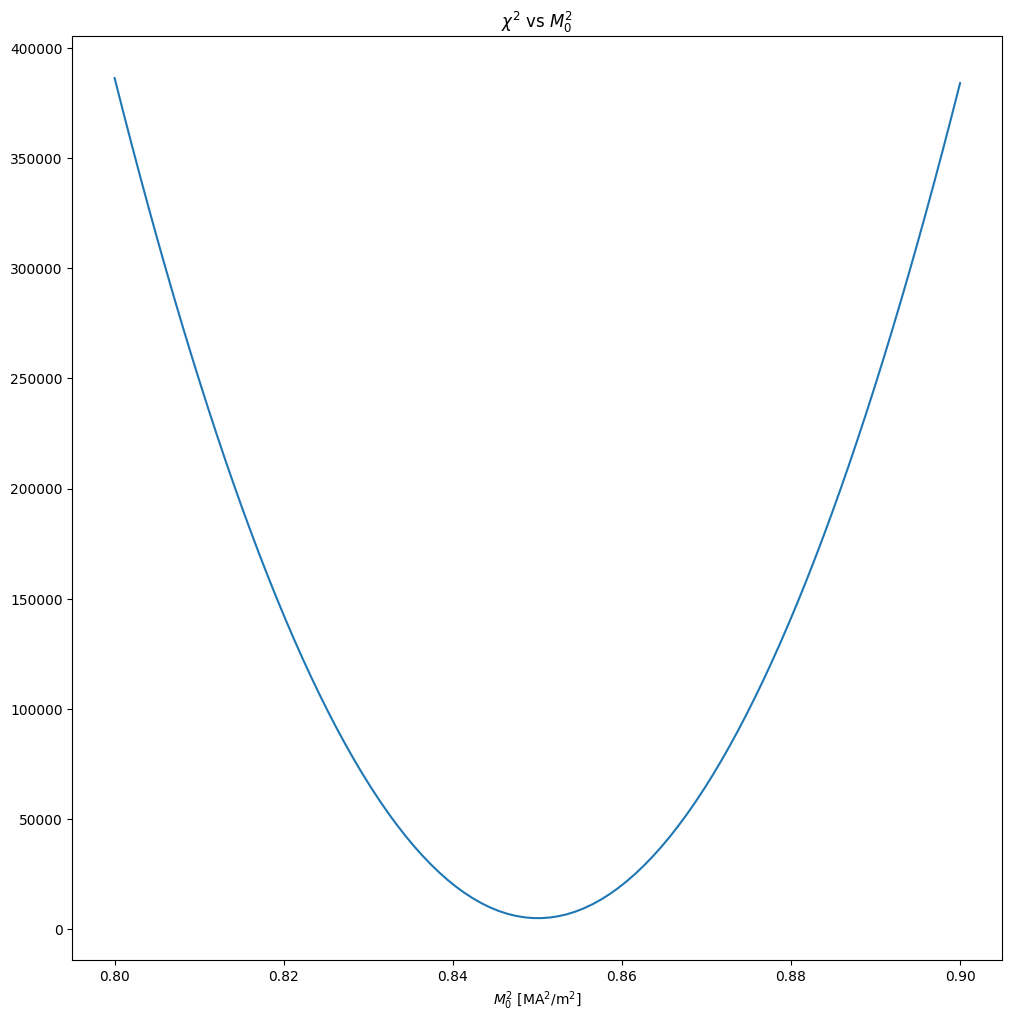

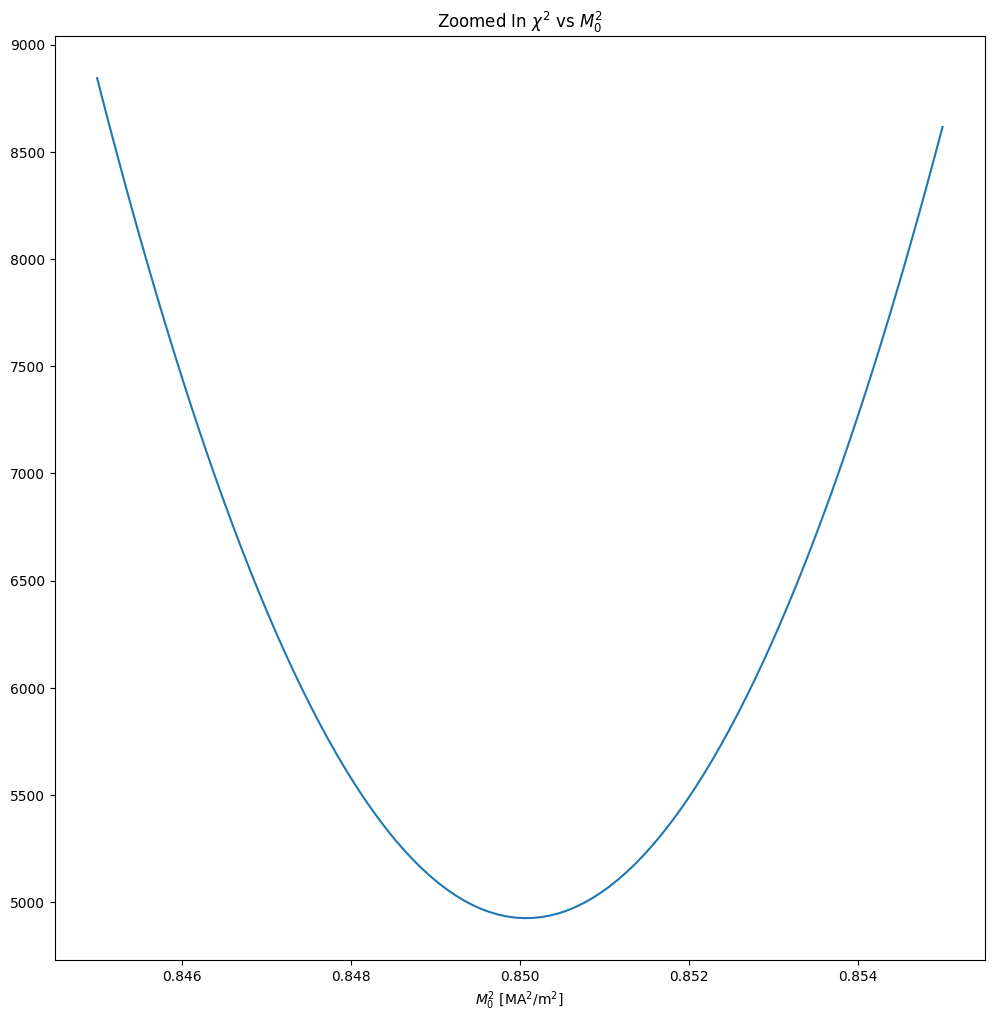

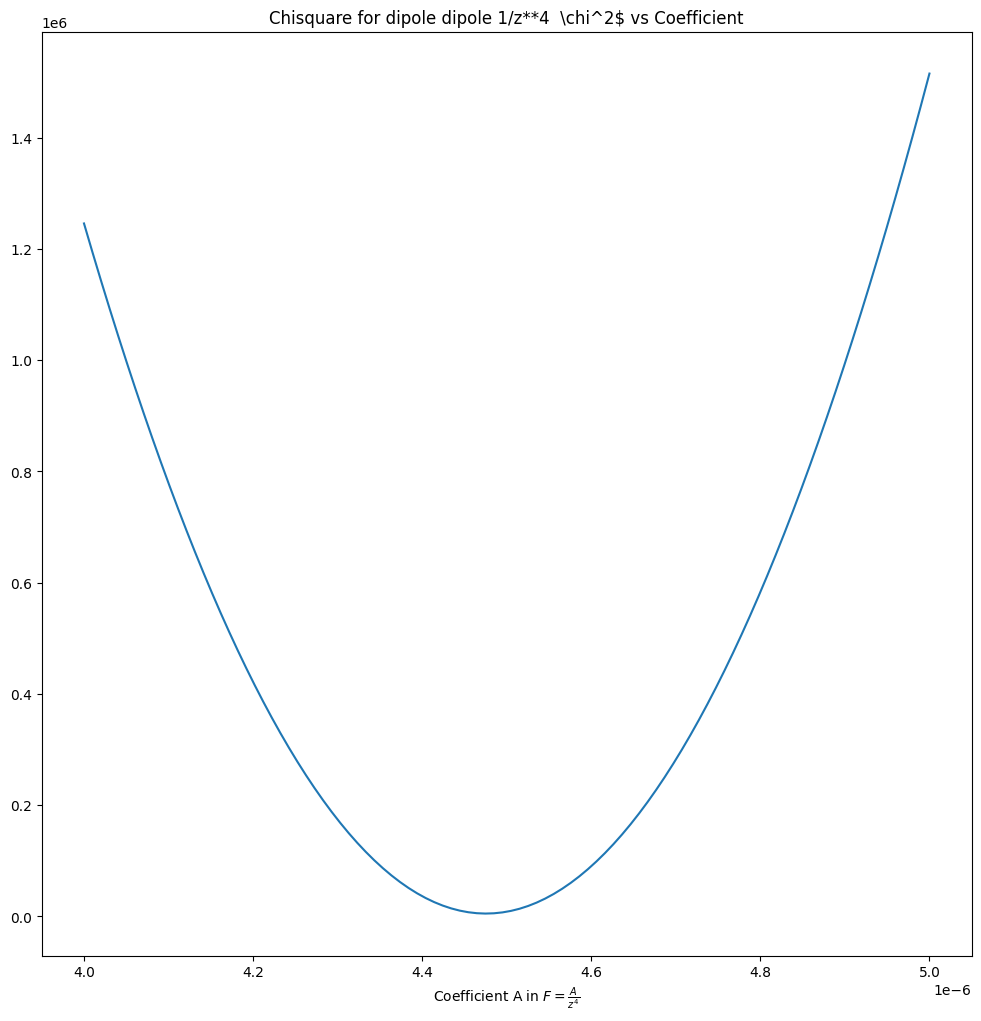

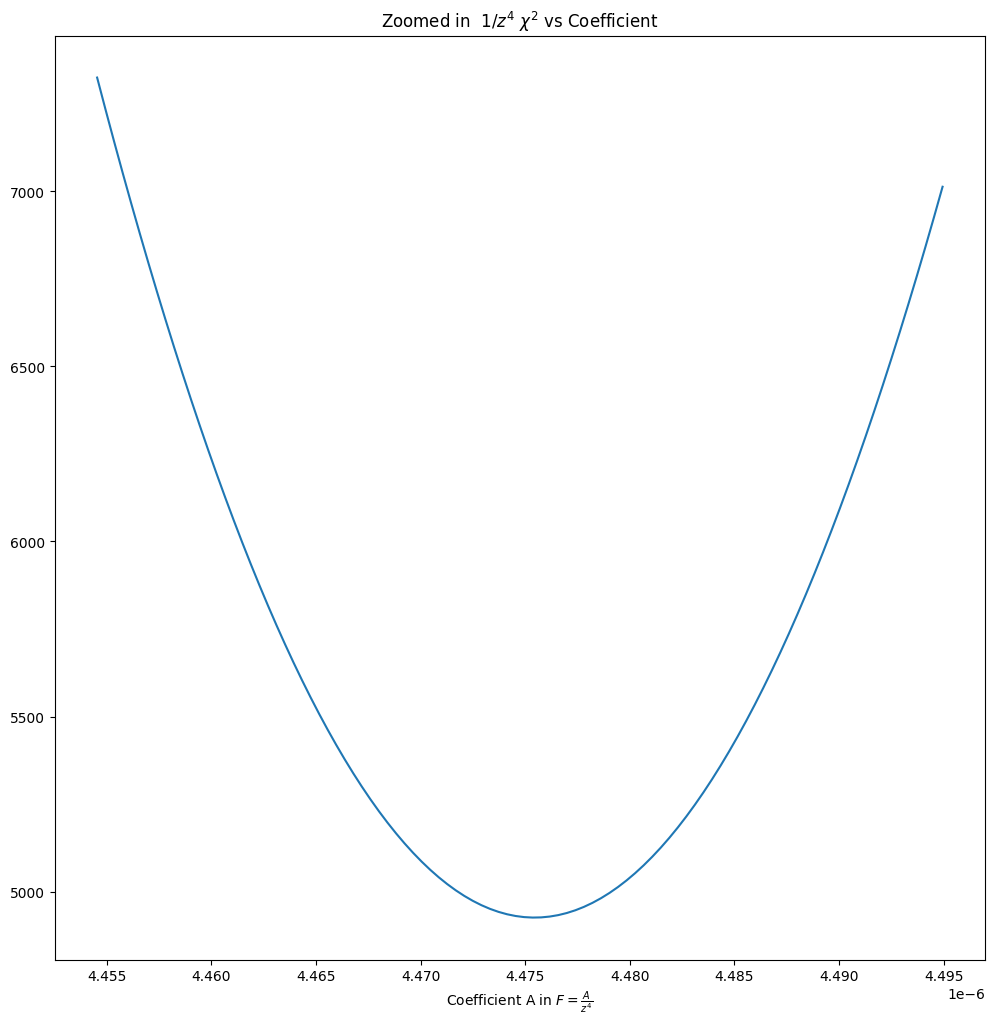

 Best fit 1/z4 :4.475359657177839e-06, chisquared 1/z4 =4926.190628473653,best model = 0.8500505050505051, chisquare=4926.209894899153


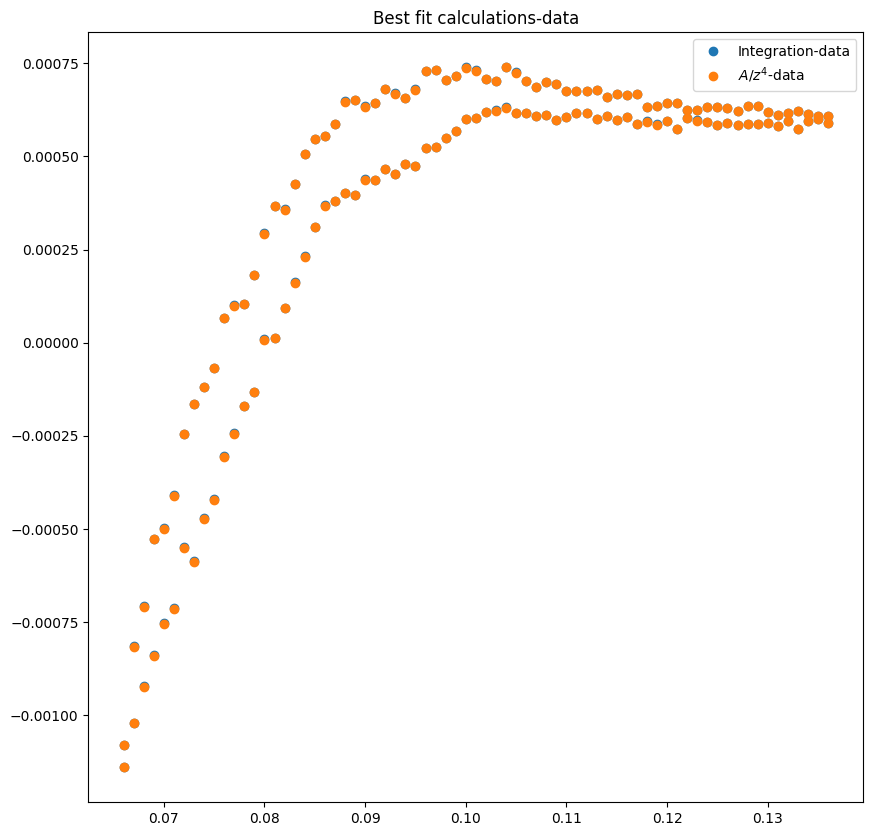

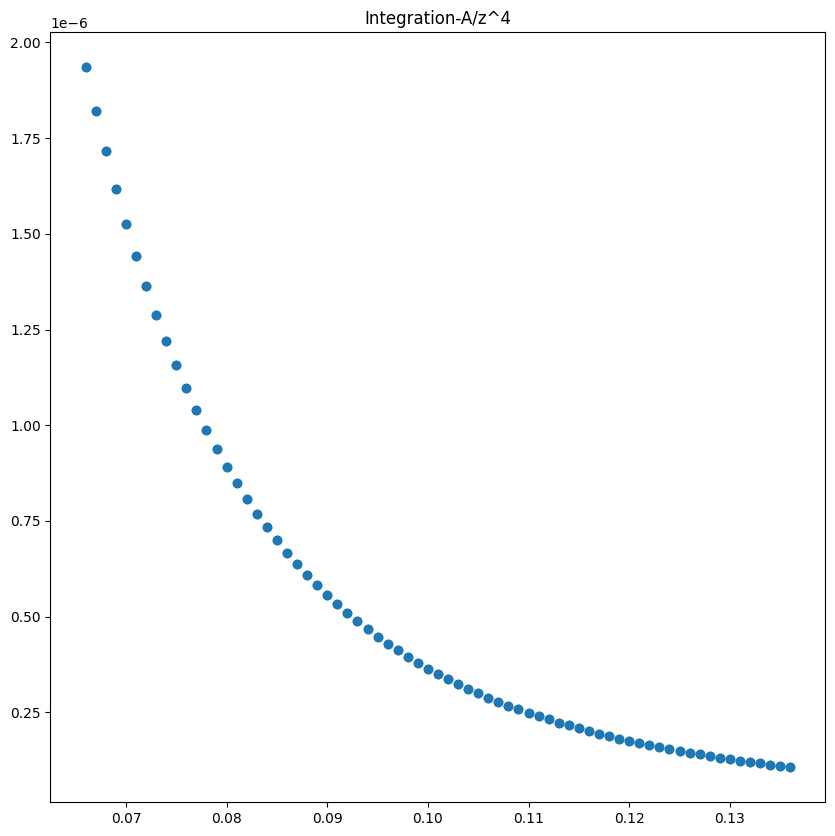

0.8500505050505051 4.475359657177839e-06 



Printout of data- distance, force, calculated force from integral, calculated force from 1/z**4
0 120.0 0.122 -0.013081838345108319 0.013081944706159924
1 119.0 0.081 -0.013473776453806121 0.013473886003309005
2 118.0 0.04 -0.013880503439528461 0.013880616297902973
3 117.0 -0.001 -0.014302694013164644 0.014302810306333036
4 116.0 -0.048 -0.014741059072853243 0.014741178932535074
5 115.0 -0.093 -0.015196347939196513 0.015196471503222706
6 114.0 -0.142 -0.01566935074700428 0.015669478159650706
7 113.0 -0.192 -0.01616090100584167 0.01616103241818374
8 112.0 -0.244 -0.016671878342722712 0.01667201391301244
9 111.0 -0.298 -0.017203211441460926 0.017203351335528142
10 110.0 -0.355 -0.01775588119447008 0.01775602558614948
11 109.0 -0.413 -0.018330924084214502 0.018331073155800428
12 108.0 -0.475 -0.01892943581305243 0.0189295897557835
13 107.0 -0.539 -0.019552575201912874 0.019552734216488586
14 106.0 -0.606 -0.02020156838011148 0.02020173267724329

In [79]:
# Start with plots of chi2 versus magnetization**2, tabulating chisquare and finding the minimum
factor=np.linspace(0.8,0.9,100)
chi2=[]
sigma=0.0001
for ff in factor:
    chi2.append(np.sum(((force[:,2]*ff*1e12-(my_data[:,4]-1.517)*9.8/1000.0)/sigma)**2))
    
plt.figure(figsize=(12,12))
plt.title(r'$\chi^2$ vs $M_0^2$')
plt.xlabel(r'$M_0^2$ [MA$^2$/m$^2$]')
plt.plot(factor,chi2)
plt.show()

factor=np.linspace(0.845,0.855,100)
chi2=[]
sigma=0.0001
for ff in factor:
    chi2.append(np.sum(((force[:,2]*ff*1e12-(my_data[:,4]-1.517)*9.8/1000.0)/sigma)**2))
    
plt.figure(figsize=(12,12))
plt.title(r'Zoomed In $\chi^2$ vs $M_0^2$')
plt.xlabel(r'$M_0^2$ [MA$^2$/m$^2$]')
plt.plot(factor,chi2)
plt.show()
best=factor[np.argmin(chi2)]

f2=np.linspace(4e-6,5e-6,100)
chi24=[]
for ff in f2:
    chi24.append( np.sum((( -ff/(my_data[:,3]/1000+0.016)**4-(my_data[:,4]-1.517)*9.8/1000.0)/sigma)**2))
    
plt.figure(figsize=(12,12))
plt.title(r'Chisquare for dipole dipole 1/z**4  \chi^2$ vs Coefficient')
plt.xlabel(r'Coefficient A in $F=\frac{A}{z^4}$')
plt.plot(f2,chi24)
plt.show()

bf=f2[np.argmin(chi24)]
f2=np.linspace(f2[np.argmin(chi24)-2],f2[np.argmin(chi24)+2],100)
chi24=[]
for ff in f2:
    chi24.append(np.sum(((-ff/(my_data[:,3]/1000+0.016)**4-(my_data[:,4]-1.517)*9.8/1000.0)/sigma)**2))
    
plt.figure(figsize=(12,12))
plt.title(r'Zoomed in  $1/z^4$ $\chi^2$ vs Coefficient')
plt.xlabel(r'Coefficient A in $F=\frac{A}{z^4}$')
plt.plot(f2,chi24)
plt.show()
bf=f2[np.argmin(chi24)]
print(f' Best fit 1/z4 :{bf}, chisquared 1/z4 ={chi24[np.argmin(chi24)]},best model = {best}, chisquare={chi2[np.argmin(chi2)]}')


plt.figure(figsize=(10,10))
plt.title('Best fit calculations-data')
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*best*1e12-(my_data[:,4]-1.517)*9.8/1000.0,'o',label='Integration-data')
plt.plot(my_data[:,3]/1000+0.016,-bf/(my_data[:,3]/1000+0.016)**4-(my_data[:,4]-1.517)*9.8/1000.0,'o',label=r'$A/z^4$-data')
plt.legend()
plt.show()

plt.figure(figsize=(10,10))
plt.title('Integration-A/z^4')
plt.plot(my_data[:,3]/1000+0.016,force[:,2]*best*1e12+bf/(my_data[:,3]/1000+0.016)**4,'o',label='Integration-data')
plt.show()
print(best,bf, '\n\n\n')

print("Printout of data- distance, force, calculated force from integral, calculated force from 1/z**4")
for i in range(len(my_data)):
    print(i,my_data[i,3],my_data[i,4],force[i,2]*best*1e12, bf/(my_data[i,3]/1000+0.016)**4)

Now do the actual fit, using scipy.optimize.minimize (which doesn't expect the root to be zero).


In [82]:
sigma=0.0001
def chi2Func(M2):
    return(np.sum(((force[:,2]*M2*1e12-(my_data[:,4]-1.517)*9.8/1000.0)/sigma)**2))

from scipy.optimize import minimize
minimize(chi2Func,np.array([0.85]))

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4926.120860250212
        x: [ 8.501e-01]
      nit: 2
      jac: [ 1.343e-03]
 hess_inv: [[ 1.840e-09]]
     nfev: 76
     njev: 33

The uncertainty on the minimized parameter is the square root of hess_inv for a single parameter. 